## 🏪 SuperStore Report Summary 

#### Data Summary and Correlation Map

              Sales     Quantity     Discount      Profit
count   9977.000000  9977.000000  9977.000000  9977.00000
mean     230.148924     3.790719     0.156278    28.69013
std      623.721439     2.226657     0.206455   234.45784
min        0.440000     1.000000     0.000000 -6599.97800
25%       17.300000     2.000000     0.000000     1.72620
50%       54.820000     3.000000     0.200000     8.67100
75%      209.970000     5.000000     0.200000    29.37200
max    22638.480000    14.000000     0.800000  8399.97600


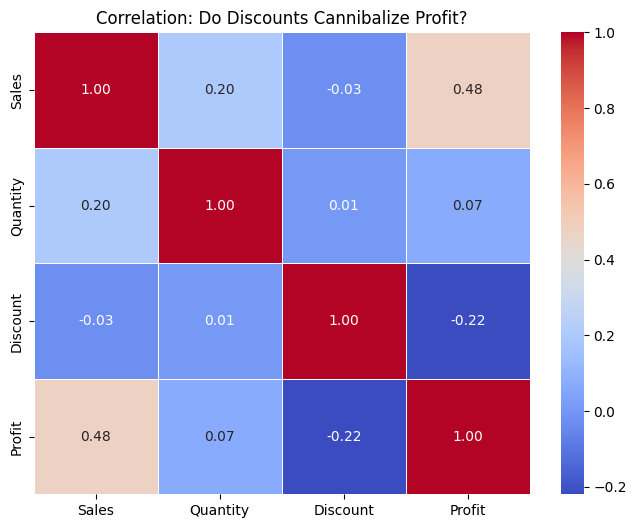

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Cleaned_SampleSuperstore.csv")
# 1. Descriptive Statistics
print(df[["Sales", "Quantity", "Discount", "Profit"]].describe())

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df[["Sales", "Quantity", "Discount", "Profit"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation: Do Discounts Cannibalize Profit?")
plt.show()

1. Missing Values Bar Chart & Heatmap (Audit)

- After cleaning, the bar chart shows zero missing cells across all 13 columns; the only pre-cleaning gap was the Discount column, where blanks had been encoded as the sentinel string " - " rather than true nulls.
- The heatmap shows no vertical banding or block patterns, meaning the missing values were scattered randomly across rows rather than concentrated in a specific region, category, or ship mode.
- Because missingness was random and limited to one column, imputation (blank discount = no discount = 0.0) was safe and did not distort any subgroup.
- Implication: the cleaning step preserved all valid rows without introducing subgroup bias.

#### Histograms (Distributions)

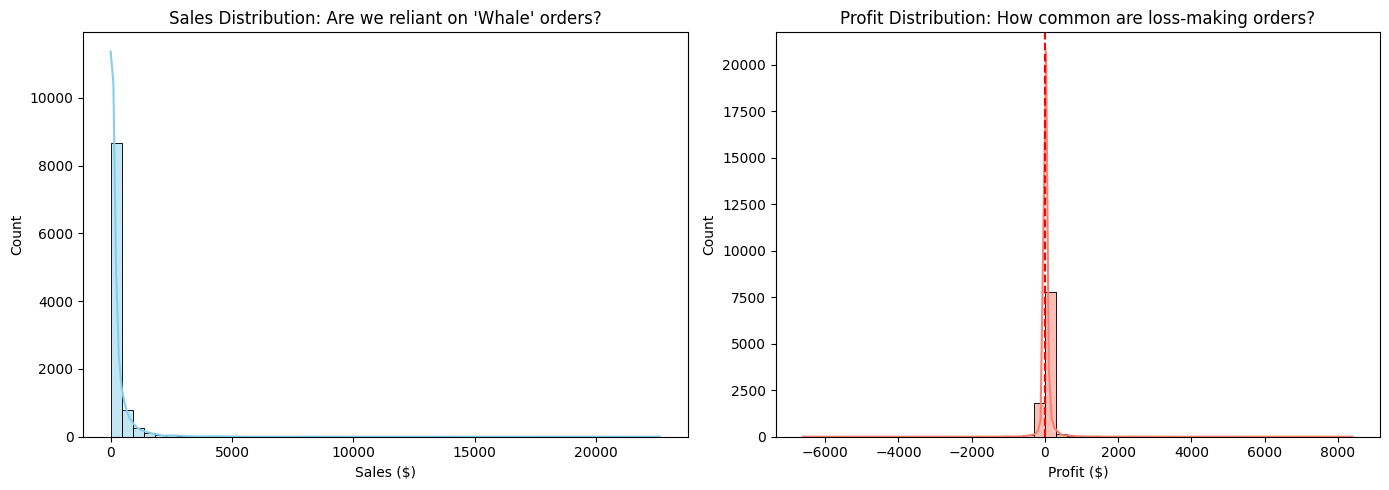

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales Distribution
sns.histplot(df["Sales"], bins=50, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Sales Distribution: Are we reliant on 'Whale' orders?")
axes[0].set_xlabel("Sales ($)")

# Profit Distribution
sns.histplot(df["Profit"], bins=50, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Profit Distribution: How common are loss-making orders?")
axes[1].axvline(0, color="red", linestyle="--")  # Mark the break-even point
axes[1].set_xlabel("Profit ($)")

plt.tight_layout()
plt.show()

2. Distribution Histograms (Sales, Profit, Discount, Quantity)
- Sales is strongly right-skewed: most order lines are small (well under $500) with a long tail of bulk orders exceeding $10–20k, so the mean is far above the median and the median is the honest "typical order" measure.
- Profit is centered slightly above zero but carries a long left tail of losses, showing that profitability is fragile at the individual order-line level even though the business is profitable overall.
- Quantity is roughly uniform across 1–14 with no skew, behaving very differently from the monetary variables.
Implication: all "average order" narratives should quote medians, and the loss tail justifies its own dedicated analysis.

#### Boxplot (Outliers)

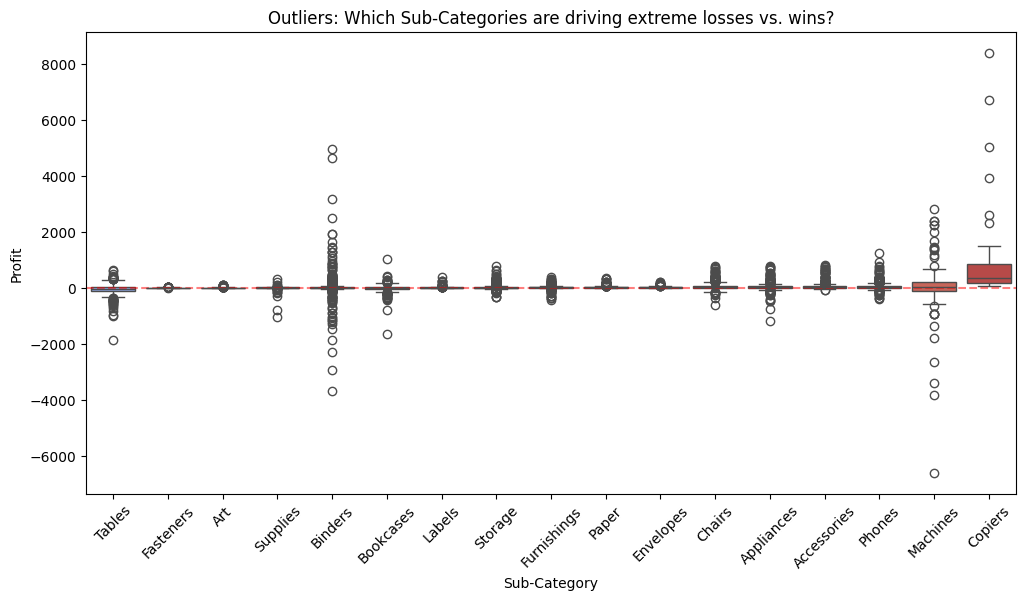

In [11]:
plt.figure(figsize=(12, 6))

# Order Sub-Categories by Median Profit to make the chart readable
sub_cat_order = df.groupby("Sub-Category")["Profit"].median().sort_values().index

sns.boxplot(
    data=df, x="Sub-Category", y="Profit", order=sub_cat_order, palette="coolwarm", hue="Sub-Category"
)
plt.title("Outliers: Which Sub-Categories are driving extreme losses vs. wins?")
plt.xticks(rotation=45)
plt.axhline(0, color="red", linestyle="--", alpha=0.5)
plt.show()

3. BOXPLOT (Outliers): 

+ Top Profit Driver (Copiers): Copiers is the highest-performing sub-category, featuring a median profit of $332.99 (elevated significantly above the $0 baseline) and the single largest positive outlier in the dataset at +$8,399.98. It maintains zero negative transactions, with a minimum profit of +$59.99.

+ Highest Downside Risk (Machines): Machines accounts for the largest single financial loss in the dataset at -$6,599.98. Although it produces high positive outliers (up to +$2,799.98), deep discounting on high-ticket equipment creates massive profit variance.

+ Highest Outlier Density (Binders): Binders exhibits the dense cluster of both positive (up to +$4,946.37) and negative outliers (down to -$3,701.89). High transaction volumes paired with aggressive discounting cause frequent extreme swings away from its near-zero median ($3.98).

+ Consistently Unprofitable Line (Tables): Tables is the primary sub-category with a median profit below zero (-$31.37) and an Interquartile Range (IQR) sitting largely in negative territory, with maximum losses reaching -$1,862.31.

+ Low-Variance / Low-Risk Lines (Paper, Fasteners, Art, Labels, Envelopes): These low-cost consumable lines display compressed, flattened boxplots around $0 with virtually no negative outliers, representing stable, predictable margins.

Text(0.5, 1.0, 'Question: How extreme are the Sales outliers?')

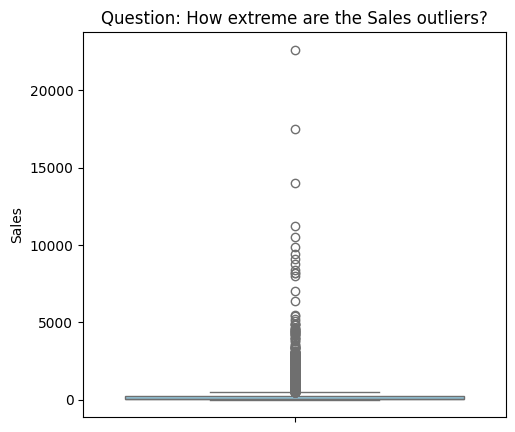

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Sales'], color='skyblue')
plt.title('Question: How extreme are the Sales outliers?')

### The Sales boxplot demonstrates extreme positive (right) skewness, where the vast majority of consumer orders are clustered at low dollar amounts while high-value transactions stretch the vertical axis up to **$22,638.48** which is of Machines.

- Compressed Central Box (IQR): The middle 50% of transaction values sit compressed near the bottom axis, with a Q1 of $17.30, a median of $54.82, and a Q3 of $209.97. The narrow Interquartile Range (IQR = $192.67) indicates that standard orders are consistently small in size.

- Low Outlier Threshold: The statistical upper whisker ($Q3 + 1.5 \times \text{IQR}$) caps out at $498.98. Any transaction exceeding ~$499 is categorized as an outlier.

- High Outlier Density: There are 1,167 outlier transactions (11.7% of all orders) forming a dense vertical column from $500 up to $5,000. This signifies that mid-to-high value corporate orders are a regular occurrence rather than isolated data entry errors.Isolated 

- High-Value Peaks: A few rare transactions break far above the primary cluster, notably orders reaching $10,499.97, $13,999.96, $17,499.95, and the maximum transaction peak at $22,638.48.Distortion of Central Metrics: These extreme outliers skew the overall mean sale amount to $230.15, which is more than four times higher than the median transaction value of $54.82.

#### Line Charts (Trends)

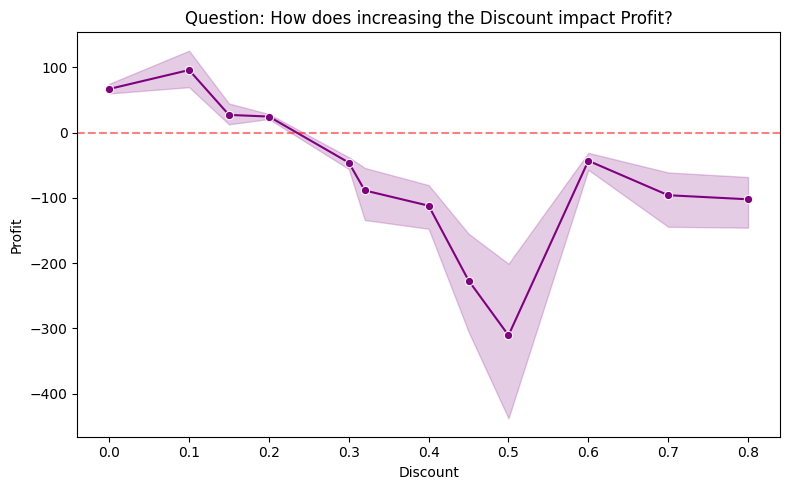

In [9]:
plt.figure(figsize=(8, 5))
if 'Order Date' in df.columns:
        df['Order Date'] = pd.to_datetime(df['Order Date'])
        trend = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum().reset_index()
        trend['Order Date'] = trend['Order Date'].astype(str)
        sns.lineplot(data=trend, x='Order Date', y='Profit', marker='o')
        plt.title('Question: What is the Profit trend over time?')
        plt.xticks(rotation=45)
else:
        sns.lineplot(data=df, x='Discount', y='Profit', errorbar=('ci', 95), marker='o', color='purple')
        plt.title('Question: How does increasing the Discount impact Profit?')
        plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

4. LINE-Chart
- Optimal Profit Zone (0% to 10% Discount):

    - 0% Discount: Full-price orders generate a healthy mean profit of +$67.02 across 4,787 transactions.

    - 10% Discount: Represents the absolute profit peak in the dataset, driving a mean profit of +$96.06 (median +$54.32). Moderate discounting effectively stimulates high-margin sales without sacrificing profitability.

- Safe Margin Threshold (15% to 20% Discount):

    - At 15% and 20% discounts, average profitability remains consistently positive at +$27.29 and +$24.72, respectively.

    - The 20% mark acts as the critical profit threshold—it is the highest discount level where transactions reliably maintain positive net profit.

- The Loss Precipice (>20% Discount):

    - Once discounting surpasses 20%, average profit immediately crosses the red dashed break-even line ($0) into negative territory.

    - 30% Discount: Mean profit drops sharply to -$45.83.

    - 40% Discount: Mean loss deepens further to -$111.93.

- Maximum Loss Peak & High Variance (50% Discount):

    - Maximum Deficit: A 50% discount triggers the single largest average profit loss in the entire dataset at -$310.70 per transaction (with minimum losses reaching -$3,839.99).

    - Confidence Interval Expansion: The shaded confidence band expands dramatically at 50%, reflecting extreme profit volatility driven by deep discounting on high-cost categories (like Machines and Binders).

- Extreme Discount Behavior (60% to 80% Discount):

    - 60% Discount: Average loss narrows temporarily to -$43.08, primary because products discounted at 60% consist mostly of lower-cost items (like Furnishings).

    - 70% & 80% Discounts: Average losses widen again to -$95.87 and -$102.12, respectively. At 70% discount, extreme individual losses reach down to -$6,599.98.

#### Donut-chart & Pie-chart & Tree-Map (***This visuals open directly in browser***)

In [ ]:
#pip install plotly
#%pip install --quiet "nbformat>=4.2.0"
import plotly.express as px

category_sales = df.groupby("Category")["Sales"].sum().reset_index()

fig_pie_category = px.pie(
    category_sales,
    names="Category",
    values="Sales",
    title="Total Sales Distribution by Category",
    color_discrete_sequence=px.colors.qualitative.Set2,
    hole=0.4,  # Donut chart for better aesthetics
)
fig_pie_category.update_traces(textposition="inside", textinfo="percent+label")
fig_pie_category.show(renderer="browser")


5. DONUT Chart

- Technology leads revenue generation: Accounting for 36.4% of total sales, Technology represents the largest share among the three categories.

- Furniture holds the middle position: Generating 32.3% of total sales, Furniture is the second-largest contributor.

- Office Supplies accounts for the smallest share: Contributing 31.3%, Office Supplies ranks last in sales volume.

- Balanced distribution across categories: Sales are nearly evenly split among all three sectors, with each category generating roughly one-third (~31%–36%) of total revenue.

- Low revenue dependency: The gap between the top-performing category (Technology) and the lowest (Office Supplies) is only 5.1 percentage points, indicating a highly diversified sales mix without heavy reliance on a single product line.

In [27]:
region_profit = df.groupby("Region")["Profit"].sum().reset_index()

fig_pie_region = px.pie(
    region_profit,
    names="Region",
    values="Profit",
    title="Profitability Share by Region",
    color_discrete_sequence=px.colors.sequential.Blues_r,
)
fig_pie_region.show(renderer="browser")

6. PIE Chart

- West dominates overall profitability: The West region generates the largest share of total profit at 37.8%.

- East is a strong secondary contributor: Accounting for 32.0% of total profit, the East region represents the second-largest profit center.

- Heavy regional concentration: Combined, the West and East regions drive 69.8% (nearly seven-tenths) of the company's total profits, showing high dependence on these two markets.

- South holds a moderate share: The South region contributes 16.3% to overall profitability, producing less than half the earnings of the West region.

- Central ranks lowest in profit contribution: Accounting for just 13.9% of total profit share, the Central region is the weakest financial performer.

- Significant regional gap: The profit share of the West region (37.8%) is more than 2.7 times larger than that of the Central region (13.9%), highlighting operational inefficiencies or aggressive discounting practices in the Central territory.

#### Tree-Map

In [21]:
treemap_data = (
    df.groupby(["Category", "Sub-Category"])
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    .reset_index()
)

fig_treemap = px.treemap(
    treemap_data,
    path=["Category", "Sub-Category"],
    values="Sales",
    color="Profit",
    color_continuous_scale="RdYlGn",  # Red-Yellow-Green scale
    color_continuous_midpoint=0,
    title="Sub-Category Performance Matrix (Size = Sales, Color = Profit)",
    hover_data=["Profit"],
)

# Formatting the layout
fig_treemap.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig_treemap.show(renderer="browser")

7. TREE-MAP Chart

- Top Profit Efficiency Outlier (Copiers): Despite having a smaller tile size ($149,528.01 in sales), Copiers features the darkest green shading in the matrix, generating the company's highest net profit at $55,617.82 (37.20% profit margin).

- Primary Volume Drivers (Phones & Chairs): Phones ($330,007.10 sales) and Chairs ($327,777.79 sales) represent the two largest individual rectangles. While Phones maintains strong profitability ($44,515.73 profit, dark green), Chairs shows a lighter green shade due to lower profit efficiency ($26,567.13 profit, 8.11% margin).

- Major Loss Centers (Tables & Bookcases): Tables is the largest negatively shaded block ($206,965.68 sales), generating a severe net loss of -$17,725.48 (-8.56% margin). Bookcases also displays a loss profile (-$3,472.56 profit on $114,880.05 sales), making Furniture the most margin-stressed category.

- High-Margin Consumables (Paper & Binders): Paper exhibits high profit density (bright green fill), converting $78,224.18 in sales into $33,944.24 in profit (43.39% margin). Binders occupies the largest space in Office Supplies ($203,409.21 sales) while yielding $30,228.00 in profit.

- Low-Yield Revenue Heavyweight (Machines): Machines accounts for a substantial share of Technology sales ($189,238.68) but displays a pale yellow tile, returning just $3,384.76 in profit (1.79% margin) due to heavy discounting and overhead costs.

#### Cards

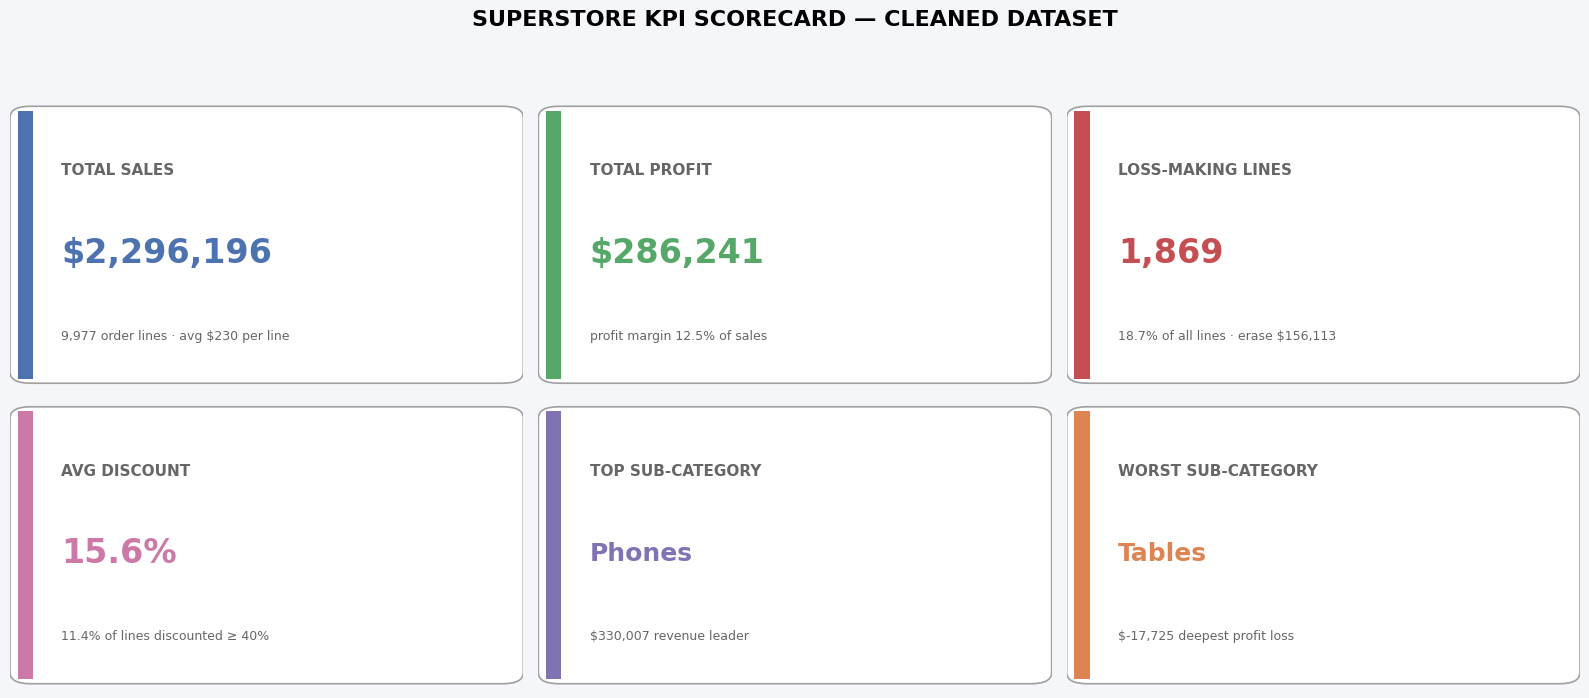

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

# ---------- 1. LOAD CLEANED DATA ----------
df = pd.read_csv("Cleaned_SampleSuperstore.csv")

# ---------- 2. COMPUTE KPIs ----------
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = total_profit / total_sales * 100
order_lines = len(df)
avg_line_val = total_sales / order_lines
avg_discount = df["Discount"].mean() * 100
heavy_disc = (df["Discount"] >= 0.4).mean() * 100
loss_mask = df["Profit"] < 0
loss_lines = loss_mask.sum()
loss_pct = loss_lines / order_lines * 100
loss_value = df.loc[loss_mask, "Profit"].sum()

sub_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
top_sub, top_sub_val = sub_sales.index[0], sub_sales.iloc[0]
worst_sub, worst_sub_val = sub_profit.index[0], sub_profit.iloc[0]


# ---------- 3. CARD DRAWING FUNCTION ----------
def draw_card(ax, title, value, subtitle, color, value_size=24):
    ax.set_axis_off()
    ax.add_patch(
        FancyBboxPatch(
            (0.015, 0.03),
            0.97,
            0.94,
            boxstyle="round,pad=0.015,rounding_size=0.04",
            transform=ax.transAxes,
            facecolor="white",
            edgecolor="#A0A0A0",
            linewidth=1.2,
            zorder=1,
        )
    )
    ax.add_patch(
        Rectangle(
            (0.015, 0.03),
            0.03,
            0.94,
            transform=ax.transAxes,
            facecolor=color,
            edgecolor="none",
            zorder=2,
        )
    )
    ax.text(
        0.10,
        0.76,
        title,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        color="#666666",
        va="center",
        zorder=3,
    )
    ax.text(
        0.10,
        0.47,
        value,
        transform=ax.transAxes,
        fontsize=value_size,
        fontweight="bold",
        color=color,
        va="center",
        zorder=3,
    )
    ax.text(
        0.10,
        0.18,
        subtitle,
        transform=ax.transAxes,
        fontsize=9,
        color="#666666",
        va="center",
        zorder=3,
    )


# ---------- 4. DEFINE THE SIX CARDS ----------
cards = [
    (
        "TOTAL SALES",
        f"${total_sales:,.0f}",
        f"{order_lines:,} order lines · avg ${avg_line_val:,.0f} per line",
        "#4C72B0",
        24,
    ),
    (
        "TOTAL PROFIT",
        f"${total_profit:,.0f}",
        f"profit margin {profit_margin:.1f}% of sales",
        "#55A868",
        24,
    ),
    (
        "LOSS-MAKING LINES",
        f"{loss_lines:,}",
        f"{loss_pct:.1f}% of all lines · erase ${abs(loss_value):,.0f}",
        "#C44E52",
        24,
    ),
    (
        "AVG DISCOUNT",
        f"{avg_discount:.1f}%",
        f"{heavy_disc:.1f}% of lines discounted ≥ 40%",
        "#CC79A7",
        24,
    ),
    ("TOP SUB-CATEGORY", top_sub, f"${top_sub_val:,.0f} revenue leader", "#8172B3", 18),
    (
        "WORST SUB-CATEGORY",
        worst_sub,
        f"${worst_sub_val:,.0f} deepest profit loss",
        "#DD8452",
        18,
    ),
]

# ---------- 5. RENDER SCORECARD ----------
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.patch.set_facecolor("#F4F6F9")
fig.suptitle(
    "SUPERSTORE KPI SCORECARD — CLEANED DATASET", fontsize=16, fontweight="bold", y=0.99
)
for ax, (t, v, s, c, vs) in zip(axes.flat, cards):
    draw_card(ax, t, v, s, c, vs)
plt.tight_layout(rect=[0, 0, 1, 0.93])
'''plt.savefig(
    "assets/kpi_scorecard.png",
    dpi=200,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)'''
plt.show()


8. CARDS

- Overall Financial Health ($2.3M Sales / $286K Profit): Total sales reach **$2,296,196** across 9,977 order lines (averaging $230 per line), generating $286,241 in net profit for a solid overall profit margin of 12.5%.

- Profit Margin Erosion ($156K Erased): Nearly 1 in 5 orders (1,869 lines or 18.7% of all transactions) operate at a loss. These loss-making transactions erase **$156,113** in accumulated profit, reducing potential total net income from $442,354 down to $286,241.

- Aggressive Discounting Impact (15.6% Average Discount): The average discount rate across all products is **15.6%**. However, 11.4% of all order lines receive heavy discounts of 40% or higher, which is the primary driver behind the 1,869 unprofitable order lines.

- Revenue Driver vs. Profit Drag:

    - Top Sub-Category (Phones): Leads overall revenue generation at **$330,007**, serving as the single largest business driver.

    - Worst Sub-Category (Tables): Represents the primary profit drain with a cumulative loss of **-$17,725**, requiring urgent pricing restructuring or vendor re-negotiation.